# Roseau Performance for Longitudinal History Mining

This notebook studies the performance of Roseau on the commit-history dataset in `data/`.

The notebook uses two complementary runtime views:

- **Roseau core time**: `api_time_ms + diff_time_ms`, which isolates the cost of API extraction and API differencing on API-changing commits.
- **Commit-to-commit analysis time**: `checkout_time_ms + api_time_ms + diff_time_ms`, which captures the end-to-end work required to move through a history.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("data")
BOOL_COLS = ["is_merge_commit", "api_changed", "has_java_changes", "has_pom_changes"]
CORE_PHASE_COLS = ["api_time_ms", "diff_time_ms", "checkout_time_ms"]
ANALYSIS_PHASE_COLS = list(dict.fromkeys(CORE_PHASE_COLS))
TIMING_COLS = ANALYSIS_PHASE_COLS + ["classpath_time_ms", "stats_time_ms"]
JAVA_FILE_COUNT_COLS = [
    "updated_java_files_count",
    "deleted_java_files_count",
    "created_java_files_count",
]
JAVA_FILE_LABELS = {
    "updated_java_files_count": "Updated Java files",
    "deleted_java_files_count": "Deleted Java files",
    "created_java_files_count": "Added Java files",
}
CATEGORY_ORDER = ["non_java", "java_no_api_change", "api_changed"]
CATEGORY_LABELS = {
    "non_java": "No Java changes",
    "java_no_api_change": "Java changes, API stable",
    "api_changed": "API changed",
}
CATEGORY_PALETTE = {
    "non_java": "#bab0ac",
    "java_no_api_change": "#4c78a8",
    "api_changed": "#f58518",
}
NUMERIC_COLS = [
    "days_since_prev_commit",
    "files_changed",
    "loc_added",
    "loc_deleted",
    *JAVA_FILE_COUNT_COLS,
    "all_api_types_count",
    "all_api_methods_count",
    "all_api_fields_count",
    "all_api_symbols_count",
    "exported_types_count",
    "exported_methods_count",
    "exported_fields_count",
    "exported_symbols_count",
    "deprecated_count",
    "internal_count",
    "all_breaking_changes_count",
    "api_breaking_changes_count",
    "excluded_breaking_changes_count",
    "binary_breaking_changes_count",
    "source_breaking_changes_count",
] + TIMING_COLS
FILE_COUNT_BINS = [-0.1, 0.5, 1.5, 2.5, 5.5, 10.5, float("inf")]
FILE_COUNT_BUCKETS = ["0", "1", "2", "3-5", "6-10", "11+"]


def q95(series):
    return series.quantile(0.95)


def q99(series):
    return series.quantile(0.99)


def positive_median_or_na(series):
    positive = series[series > 0]
    return positive.median() if not positive.empty else pd.NA


def positive_median(series):
    positive = series[series > 0]
    return positive.median() if not positive.empty else 0


def positive_quantile(series, quantile):
    positive = series[series > 0]
    return positive.quantile(quantile) if not positive.empty else 0


def safe_corr(frame, x_col, y_col, method="pearson"):
    clean = frame[[x_col, y_col]].dropna()
    clean = clean[(clean[x_col] > 0) & (clean[y_col] > 0)]
    if len(clean) < 2 or clean[x_col].nunique() < 2 or clean[y_col].nunique() < 2:
        return pd.NA
    return clean.corr(method=method).iloc[0, 1]


frames = []
for csv_path in sorted(DATA_DIR.glob("*-commits.csv")):
    df = pd.read_csv(csv_path, low_memory=False)
    df["library"] = df["library"].fillna(csv_path.stem.removesuffix("-commits"))
    frames.append(df)

commits_df = pd.concat(frames, ignore_index=True)
commits_df["date_utc"] = pd.to_datetime(commits_df["date_utc"], errors="coerce", utc=True)

for col in BOOL_COLS:
    commits_df[col] = commits_df[col].astype(str).str.lower().eq("true")
for col in NUMERIC_COLS:
    if col not in commits_df.columns:
        commits_df[col] = 0
    commits_df[col] = pd.to_numeric(commits_df[col], errors="coerce").fillna(0)

exported_symbol_fallback = (
    commits_df["exported_types_count"]
    + commits_df["exported_methods_count"]
    + commits_df["exported_fields_count"]
)
commits_df["exported_symbols_count"] = commits_df["exported_symbols_count"].where(
    commits_df["exported_symbols_count"] > 0, exported_symbol_fallback
)
commits_df["loc_churn"] = commits_df["loc_added"] + commits_df["loc_deleted"]
commits_df["java_file_churn"] = commits_df[JAVA_FILE_COUNT_COLS].sum(axis=1)
commits_df["core_time_ms"] = commits_df[CORE_PHASE_COLS].sum(axis=1)
commits_df["analysis_time_ms"] = commits_df[ANALYSIS_PHASE_COLS].sum(axis=1)
commits_df["api_filtered_before_diff"] = commits_df["has_java_changes"] & ~commits_df["api_changed"]
commits_df["commit_category"] = "non_java"
commits_df.loc[commits_df["has_java_changes"], "commit_category"] = "java_no_api_change"
commits_df.loc[commits_df["api_changed"], "commit_category"] = "api_changed"
commits_df["commit_category_label"] = commits_df["commit_category"].map(CATEGORY_LABELS)
commits_df["breaking_changes_count"] = commits_df["api_breaking_changes_count"]
commits_df["has_breaks"] = commits_df["api_breaking_changes_count"] > 0

java_df = commits_df[commits_df["has_java_changes"]].copy()
filtered_java_df = commits_df[commits_df["api_filtered_before_diff"]].copy()
api_changed_df = commits_df[commits_df["api_changed"]].copy()
phase_df = api_changed_df[api_changed_df["core_time_ms"] > 0].copy()

print(f"Libraries: {commits_df['library'].nunique()}")
print(f"Commit rows: {len(commits_df):,}")
print(f"Java-touching commits: {len(java_df):,}")
print(f"Java commits filtered before diffing: {len(filtered_java_df):,}")
print(f"API-changing commits: {len(api_changed_df):,}")


Libraries: 29
Commit rows: 185,817
Java-touching commits: 119,077
Java commits filtered before diffing: 96,302
API-changing commits: 22,775


## Descriptive Profile of the Studied Libraries

Before interpreting runtime variation, it helps to characterize the corpus itself. The table below combines repository-level Java LOC from `libraries.csv` with history-level descriptors derived from the mined commit histories. Because several subjects come from multi-module repositories, the LOC column is reported at the repository level, while the `Library` column keeps the specific mined artifact or module in view.


In [2]:
library_loc_df = pd.read_csv("libraries.csv").rename(
    columns={"folder": "repository_folder", "java_code_lines": "repository_java_loc"}
)

repo_parts = commits_df["commit_url"].fillna("").astype(str).str.split("/")
commits_df["repository_slug"] = repo_parts.str[3].fillna("") + "/" + repo_parts.str[4].fillna("")
commits_df["repository_folder"] = repo_parts.str[4].fillna("")


def format_count_share(count, total):
    share = count / total if total else pd.NA
    return f"{count:,} ({share:.1%})" if pd.notna(share) else f"{count:,}"


descriptor_rows = []
for library, df in commits_df.groupby("library", sort=True):
    d = df.sort_values(["date_utc", "commit_sha"]).reset_index(drop=True)
    dates = d["date_utc"].dropna()
    first_commit = dates.min() if not dates.empty else pd.NaT
    last_commit = dates.max() if not dates.empty else pd.NaT
    lifespan_years = (last_commit - first_commit).days / 365.25 if len(dates) else pd.NA
    commits = len(d)
    java_commits = int(d["has_java_changes"].sum())
    api_commits = int(d["api_changed"].sum())
    break_commits = int((d["api_breaking_changes_count"] > 0).sum())

    descriptor_rows.append(
        {
            "library": library,
            "repository_slug": d["repository_slug"].dropna().iloc[0],
            "repository_folder": d["repository_folder"].dropna().iloc[0],
            "first_commit": first_commit.date().isoformat() if pd.notna(first_commit) else pd.NA,
            "last_commit": last_commit.date().isoformat() if pd.notna(last_commit) else pd.NA,
            "lifespan_years": lifespan_years,
            "commits": commits,
            "commits_per_year": commits / lifespan_years if pd.notna(lifespan_years) and lifespan_years > 0 else pd.NA,
            "java_commits_pct": format_count_share(java_commits, commits),
            "api_changed_commits_pct": format_count_share(api_commits, commits),
            "break_commits_pct": format_count_share(break_commits, commits),
            "peak_exported_symbols": int(d["exported_symbols_count"].max()),
            "tagged_revisions": d["tag"].fillna("").astype(str).replace("", pd.NA).dropna().nunique(),
        }
    )

library_descriptor_df = (
    pd.DataFrame(descriptor_rows)
    .merge(library_loc_df, on="repository_folder", how="left")
    .sort_values(["repository_java_loc", "commits"], ascending=[False, False])
)

missing_loc_libraries = library_descriptor_df.loc[
    library_descriptor_df["repository_java_loc"].isna(),
    ["library", "repository_slug"],
]
loc_note = (
    "Repository Java LOC comes from `libraries.csv`, so it is repository-level rather than module-level for multi-module subjects."
)
if not missing_loc_libraries.empty:
    missing_names = ", ".join(
        f"`{row.library}` ({row.repository_slug})" for row in missing_loc_libraries.itertuples(index=False)
    )
    loc_note += f" LOC is currently missing for {missing_names} because their repository folders are not listed in `libraries.csv`."
display(Markdown(loc_note))

library_descriptor_table = library_descriptor_df[[
    "library",
    "repository_slug",
    "repository_java_loc",
    "first_commit",
    "last_commit",
    "lifespan_years",
    "commits",
    "commits_per_year",
    "java_commits_pct",
    "api_changed_commits_pct",
    "break_commits_pct",
    "peak_exported_symbols",
]].rename(columns={
    "library": "Library",
    "repository_slug": "Repository",
    "repository_java_loc": "Repository Java LOC",
    "first_commit": "First commit",
    "last_commit": "Last commit",
    "lifespan_years": "Lifespan (years)",
    "commits": "Commits",
    "commits_per_year": "Commits/year",
    "java_commits_pct": "Java-touching commits (%)",
    "api_changed_commits_pct": "API-changing commits (%)",
    "break_commits_pct": "Break commits (%)",
    "peak_exported_symbols": "Peak exported API symbols",
})

display(
    library_descriptor_table.style.format(
        {
            "Repository Java LOC": "{:,.0f}",
            "Lifespan (years)": "{:.1f}",
            "Commits": "{:,.0f}",
            "Commits/year": "{:.1f}",
            "Peak exported API symbols": "{:,.0f}",
        }
    ).hide(axis="index")
)

Repository Java LOC comes from `libraries.csv`, so it is repository-level rather than module-level for multi-module subjects. LOC is currently missing for `protobuf-java` (protocolbuffers/protobuf) because their repository folders are not listed in `libraries.csv`.

Library,Repository,Repository Java LOC,First commit,Last commit,Lifespan (years),Commits,Commits/year,Java-touching commits (%),API-changing commits (%),Break commits (%),Peak exported API symbols
spring-context,spring-projects/spring-framework,"848,956",2008-10-21,2026-03-24,17.4,"28,055",1610.7,"22,128 (78.9%)",970 (3.5%),424 (1.5%),"3,319"
fastjson,alibaba/fastjson2,"443,100",2022-04-17,2026-03-15,3.9,"4,612",1180.5,"3,574 (77.5%)",920 (19.9%),352 (7.6%),"4,889"
guava,google/guava,"352,293",2009-09-15,2026-03-23,16.5,"7,253",439.1,"6,511 (89.8%)","1,879 (25.9%)",64 (0.9%),"5,082"
org.osgi.core,osgi/osgi,"282,311",2004-07-02,2026-03-11,21.7,"12,459",574.4,"7,283 (58.5%)",204 (1.6%),114 (0.9%),674
h2,h2database/h2database,"244,590",2006-12-15,2026-01-31,19.1,"8,024",419.5,"6,992 (87.1%)","2,393 (29.8%)","1,380 (17.2%)","10,704"
assertj-core,assertj/assertj,"230,342",2010-09-07,2026-03-25,15.5,"4,263",274.2,"2,437 (57.2%)","1,146 (26.9%)",416 (9.8%),"7,994"
mysql-connector-j,mysql/mysql-connector-j,"215,039",2002-03-13,2025-12-17,23.8,"2,633",110.8,"2,149 (81.6%)","1,133 (43.0%)",608 (23.1%),"13,561"
maven-plugin-api,apache/maven,"206,826",2004-08-09,2026-03-24,21.6,"12,030",556.5,"7,143 (59.4%)",60 (0.5%),28 (0.2%),270
jackson-databind,FasterXML/jackson-databind,"196,563",2011-12-23,2026-03-24,14.2,"6,751",473.8,"5,549 (82.2%)","2,425 (35.9%)","1,257 (18.6%)","9,264"
junit-jupiter-api,junit-team/junit-framework,"133,200",2015-10-24,2026-03-23,10.4,"9,909",951.7,"5,279 (53.3%)",401 (4.0%),173 (1.7%),855


## Corpus-Level Summary

The CSV schema supports three nested views of the history mining workload.

- **All commits**, because whole-history throughput still matters for longitudinal mining.
- **Java-touching commits**, because Roseau may need to check out the project and compute an API snapshot even when the public API remains unchanged.
- **API-changing commits**, because these are the rows that actually trigger the full API + diff workflow.>

In [3]:
analysis_total_s = commits_df["analysis_time_ms"].sum() / 1000

category_summary = commits_df.groupby("commit_category").apply(
    lambda df: pd.Series(
        {
            "commits": len(df),
            "median_checkout_time_ms": positive_median_or_na(df["checkout_time_ms"]),
            "median_api_time_ms": (
                positive_median_or_na(df["api_time_ms"])
                if df.name in {"java_no_api_change", "api_changed"}
                else pd.NA
            ),
            "median_diff_time_ms": (
                positive_median_or_na(df["diff_time_ms"])
                if df.name == "api_changed"
                else pd.NA
            ),
        }
    ),
    include_groups=False,
).reindex(CATEGORY_ORDER)
category_summary["share_all_commits"] = category_summary["commits"] / len(commits_df)
category_summary["share_java_commits"] = 0.0
if len(java_df) > 0:
    category_summary.loc["java_no_api_change", "share_java_commits"] = len(filtered_java_df) / len(java_df)
    category_summary.loc["api_changed", "share_java_commits"] = len(api_changed_df) / len(java_df)
category_summary["label"] = [CATEGORY_LABELS[key] for key in category_summary.index]
category_summary = category_summary[[
    "label",
    "commits",
    "share_all_commits",
    "share_java_commits",
    "median_checkout_time_ms",
    "median_api_time_ms",
    "median_diff_time_ms",
]].round(3)

corpus_summary = pd.DataFrame(
    [
        {"metric": "libraries", "value": commits_df["library"].nunique()},
        {"metric": "commit_rows", "value": len(commits_df)},
        {"metric": "java_commit_share", "value": commits_df["has_java_changes"].mean()},
        {"metric": "api_changed_share_all_commits", "value": commits_df["api_changed"].mean()},
        {"metric": "api_changed_share_java_commits", "value": api_changed_df.shape[0] / len(java_df)},
        {"metric": "java_filtered_before_diff_share", "value": filtered_java_df.shape[0] / len(java_df)},
        {"metric": "total_analysis_time_hours", "value": analysis_total_s / 3600},
        {"metric": "total_checkout_time_hours", "value": commits_df["checkout_time_ms"].sum() / 1000 / 3600},
        {"metric": "total_api_time_hours", "value": commits_df["api_time_ms"].sum() / 1000 / 3600},
        {"metric": "total_diff_time_hours", "value": commits_df["diff_time_ms"].sum() / 1000 / 3600},
        {"metric": "global_analysis_throughput_cps", "value": len(commits_df) / analysis_total_s},
        {"metric": "global_analysis_ms_per_commit", "value": commits_df["analysis_time_ms"].sum() / len(commits_df)},
        {"metric": "all_breaking_changes_total", "value": commits_df["all_breaking_changes_count"].sum()},
        {"metric": "api_breaking_changes_total", "value": commits_df["api_breaking_changes_count"].sum()},
        {
            "metric": "excluded_or_internal_break_share",
            "value": commits_df["excluded_breaking_changes_count"].sum() / commits_df["all_breaking_changes_count"].sum()
            if commits_df["all_breaking_changes_count"].sum()
            else 0,
        },
    ]
).round(4)

phase_summary = (
    commits_df[["checkout_time_ms", "api_time_ms", "diff_time_ms"]]
    .agg(["median", q99, "max"])
    .T.rename(columns={"q99": "p99"})
    .rename(
        index={
            "checkout_time_ms": "Git checkout",
            "api_time_ms": "API construction",
            "diff_time_ms": "API diff",
        }
    )
    .round(2)
)

phase_share = phase_df[CORE_PHASE_COLS].div(phase_df["core_time_ms"], axis=0)
phase_share = phase_share.median().rename("median_share").round(3)


def summarize_library(df):
    java = df[df["has_java_changes"]]
    filtered = df[df["api_filtered_before_diff"]]
    api = df[df["api_changed"]]
    total_analysis_s = df["analysis_time_ms"].sum() / 1000
    java_commits = len(java)
    api_commits = len(api)
    return pd.Series(
        {
            "commits": len(df),
            "java_commits": java_commits,
            "java_no_api_commits": len(filtered),
            "api_changed_commits": api_commits,
            "api_changed_share_all_commits": df["api_changed"].mean(),
            "java_filtered_before_diff_share": len(filtered) / java_commits if java_commits else 0,
            "api_changed_share_within_java": api_commits / java_commits if java_commits else 0,
            "total_analysis_s": total_analysis_s,
            "total_analysis_min": total_analysis_s / 60,
            "analysis_throughput_cps": len(df) / total_analysis_s if total_analysis_s else 0,
            "analysis_ms_per_commit": df["analysis_time_ms"].sum() / len(df),
            "total_api_s": df["api_time_ms"].sum() / 1000,
            "total_diff_s": df["diff_time_ms"].sum() / 1000,
            "total_core_s": df["core_time_ms"].sum() / 1000,
            "median_api_ms": positive_median(java["api_time_ms"]),
            "median_diff_ms": positive_median(api["diff_time_ms"]),
            "median_core_ms": positive_median(api["core_time_ms"]),
            "p95_core_ms": positive_quantile(api["core_time_ms"], 0.95),
            "median_java_files_java_commits": java["java_file_churn"].median() if java_commits else 0,
            "median_java_files_api_changed": api["java_file_churn"].median() if api_commits else 0,
            "max_exported_symbols": df["exported_symbols_count"].max(),
            "api_breaking_changes_total": df["api_breaking_changes_count"].sum(),
            "excluded_breaking_changes_total": df["excluded_breaking_changes_count"].sum(),
            "excluded_or_internal_break_share": (
                df["excluded_breaking_changes_count"].sum() / df["all_breaking_changes_count"].sum()
                if df["all_breaking_changes_count"].sum()
                else 0
            ),
        }
    )


library_history_df = (
    commits_df.groupby("library", group_keys=False)
    .apply(summarize_library, include_groups=False)
    .sort_values("total_analysis_s", ascending=False)
    .round(3)
)

library_phase_share = phase_df.groupby("library")[CORE_PHASE_COLS].median()
library_phase_share = library_phase_share.div(library_phase_share.sum(axis=1), axis=0)

library_corr_exported = pd.Series(
    {lib: safe_corr(df, "exported_symbols_count", "core_time_ms") for lib, df in phase_df.groupby("library")},
    name="corr_core_vs_api_size",
)
library_corr_java_files = pd.Series(
    {lib: safe_corr(df, "java_file_churn", "core_time_ms") for lib, df in phase_df.groupby("library")},
    name="corr_core_vs_java_file_churn",
)

library_phase_summary = library_history_df[[
    "commits",
    "java_commits",
    "java_no_api_commits",
    "api_changed_commits",
    "java_filtered_before_diff_share",
    "total_analysis_s",
    "analysis_throughput_cps",
    "analysis_ms_per_commit",
    "total_core_s",
    "median_core_ms",
    "p95_core_ms",
    "max_exported_symbols",
]].copy()
library_phase_summary["total_analysis_min"] = library_phase_summary["total_analysis_s"] / 60
library_phase_summary["total_core_min"] = library_phase_summary["total_core_s"] / 60
library_phase_summary["median_api_share"] = library_phase_share["api_time_ms"]
library_phase_summary["median_diff_share"] = library_phase_share["diff_time_ms"]
library_phase_summary["corr_core_vs_api_size"] = library_corr_exported
library_phase_summary["corr_core_vs_java_file_churn"] = library_corr_java_files
library_phase_summary = library_phase_summary[[
    "commits",
    "java_commits",
    "java_no_api_commits",
    "api_changed_commits",
    "java_filtered_before_diff_share",
    "total_analysis_min",
    "analysis_throughput_cps",
    "analysis_ms_per_commit",
    "total_core_min",
    "median_core_ms",
    "p95_core_ms",
    "median_api_share",
    "median_diff_share",
    "corr_core_vs_api_size",
    "corr_core_vs_java_file_churn",
    "max_exported_symbols",
]].sort_values(["total_analysis_min", "median_core_ms"], ascending=[False, False]).round(3)

display(corpus_summary)
display(category_summary)
display(phase_summary)
display(phase_share.to_frame())
display(library_history_df)
display(library_phase_summary)


,metric,value
0,libraries,29.0000
1,commit_rows,185817.0000
2,java_commit_share,0.6408
3,api_changed_share_all_commits,0.1226
4,api_changed_share_java_commits,0.1913
5,java_filtered_before_diff_share,0.8087
6,total_analysis_time_hours,2.6406
7,total_checkout_time_hours,1.9605
8,total_api_time_hours,0.4519
9,total_diff_time_hours,0.2283


,label,commits,share_all_commits,share_java_commits,median_checkout_time_ms,median_api_time_ms,median_diff_time_ms
commit_category,,,,,,,
non_java,No Java changes,66740.0,0.359,0.000,<NA>,<NA>,<NA>
java_no_api_change,"Java changes, API stable",96302.0,0.518,0.809,36.0,15.0,<NA>
api_changed,API changed,22775.0,0.123,0.191,16.0,20.0,25.0


,median,p99,max
Git checkout,11.0,223.0,8781.0
API construction,0.0,96.0,766.0
API diff,0.0,90.0,275.0


,median_share
api_time_ms,0.320
diff_time_ms,0.345
checkout_time_ms,0.263


,commits,java_commits,java_no_api_commits,api_changed_commits,api_changed_share_all_commits,java_filtered_before_diff_share,api_changed_share_within_java,total_analysis_s,total_analysis_min,analysis_throughput_cps,...,median_api_ms,median_diff_ms,median_core_ms,p95_core_ms,median_java_files_java_commits,median_java_files_api_changed,max_exported_symbols,api_breaking_changes_total,excluded_breaking_changes_total,excluded_or_internal_break_share
library,,,,,,,,,,,,,,,,,,,,,
spring-context,28055.0,22128.0,21158.0,970.0,0.035,0.956,0.044,3403.060,56.718,8.244,...,12.0,27.0,165.0,271.00,2.0,5.0,3319.0,3174.0,0.0,0.000
org.osgi.core,12459.0,7283.0,7079.0,204.0,0.016,0.972,0.028,964.832,16.081,12.913,...,8.0,3.0,161.0,241.85,1.0,2.0,674.0,455.0,0.0,0.000
jackson-databind,6751.0,5549.0,3124.0,2425.0,0.359,0.563,0.437,648.716,10.812,10.407,...,40.0,104.0,164.0,404.00,2.0,4.0,9264.0,32414.0,3070.0,0.087
maven-plugin-api,12030.0,7143.0,7083.0,60.0,0.005,0.992,0.008,595.623,9.927,20.197,...,3.0,1.0,53.0,105.80,2.0,8.0,270.0,77.0,0.0,0.000
guava,7253.0,6511.0,4632.0,1879.0,0.259,0.711,0.289,512.653,8.544,14.148,...,45.0,36.0,106.0,172.10,2.0,4.0,5082.0,556.0,1634.0,0.746
h2,8024.0,6992.0,4599.0,2393.0,0.298,0.658,0.342,449.159,7.486,17.864,...,26.0,52.0,108.0,212.00,2.0,6.0,10704.0,35406.0,0.0,0.000
log4j-core,11238.0,7071.0,5787.0,1284.0,0.114,0.818,0.182,416.783,6.946,26.964,...,13.0,26.0,78.5,191.85,1.0,3.0,5757.0,3267.0,207.0,0.060
fastjson,4612.0,3574.0,2654.0,920.0,0.199,0.743,0.257,391.538,6.526,11.779,...,64.0,15.0,143.5,212.00,2.0,6.0,4889.0,1906.0,155.0,0.075
log4j-api,10292.0,7029.0,6567.0,462.0,0.045,0.934,0.066,348.879,5.815,29.500,...,8.0,39.0,92.0,190.95,1.0,4.0,2418.0,1998.0,83.0,0.040


,commits,java_commits,java_no_api_commits,api_changed_commits,java_filtered_before_diff_share,total_analysis_min,analysis_throughput_cps,analysis_ms_per_commit,total_core_min,median_core_ms,p95_core_ms,median_api_share,median_diff_share,corr_core_vs_api_size,corr_core_vs_java_file_churn,max_exported_symbols
library,,,,,,,,,,,,,,,,
spring-context,28055.0,22128.0,21158.0,970.0,0.956,56.718,8.244,121.300,56.718,165.0,271.00,0.068,0.167,0.791,0.489,3319.0
org.osgi.core,12459.0,7283.0,7079.0,204.0,0.972,16.081,12.913,77.441,16.081,161.0,241.85,0.050,0.019,0.777,0.540,674.0
jackson-databind,6751.0,5549.0,3124.0,2425.0,0.563,10.812,10.407,96.092,10.812,164.0,404.00,0.275,0.650,0.638,0.132,9264.0
maven-plugin-api,12030.0,7143.0,7083.0,60.0,0.992,9.927,20.197,49.511,9.927,53.0,105.80,0.039,0.019,0.376,0.468,270.0
guava,7253.0,6511.0,4632.0,1879.0,0.711,8.544,14.148,70.682,8.544,106.0,172.10,0.430,0.336,0.463,0.772,5082.0
h2,8024.0,6992.0,4599.0,2393.0,0.658,7.486,17.864,55.977,7.486,108.0,212.00,0.364,0.473,0.632,0.566,10704.0
log4j-core,11238.0,7071.0,5787.0,1284.0,0.818,6.946,26.964,37.087,6.946,78.5,191.85,0.208,0.338,0.920,0.308,5757.0
fastjson,4612.0,3574.0,2654.0,920.0,0.743,6.526,11.779,84.895,6.526,143.5,212.00,0.479,0.106,0.859,0.281,4889.0
log4j-api,10292.0,7029.0,6567.0,462.0,0.934,5.815,29.500,33.898,5.815,92.0,190.95,0.101,0.438,0.892,0.383,2418.0


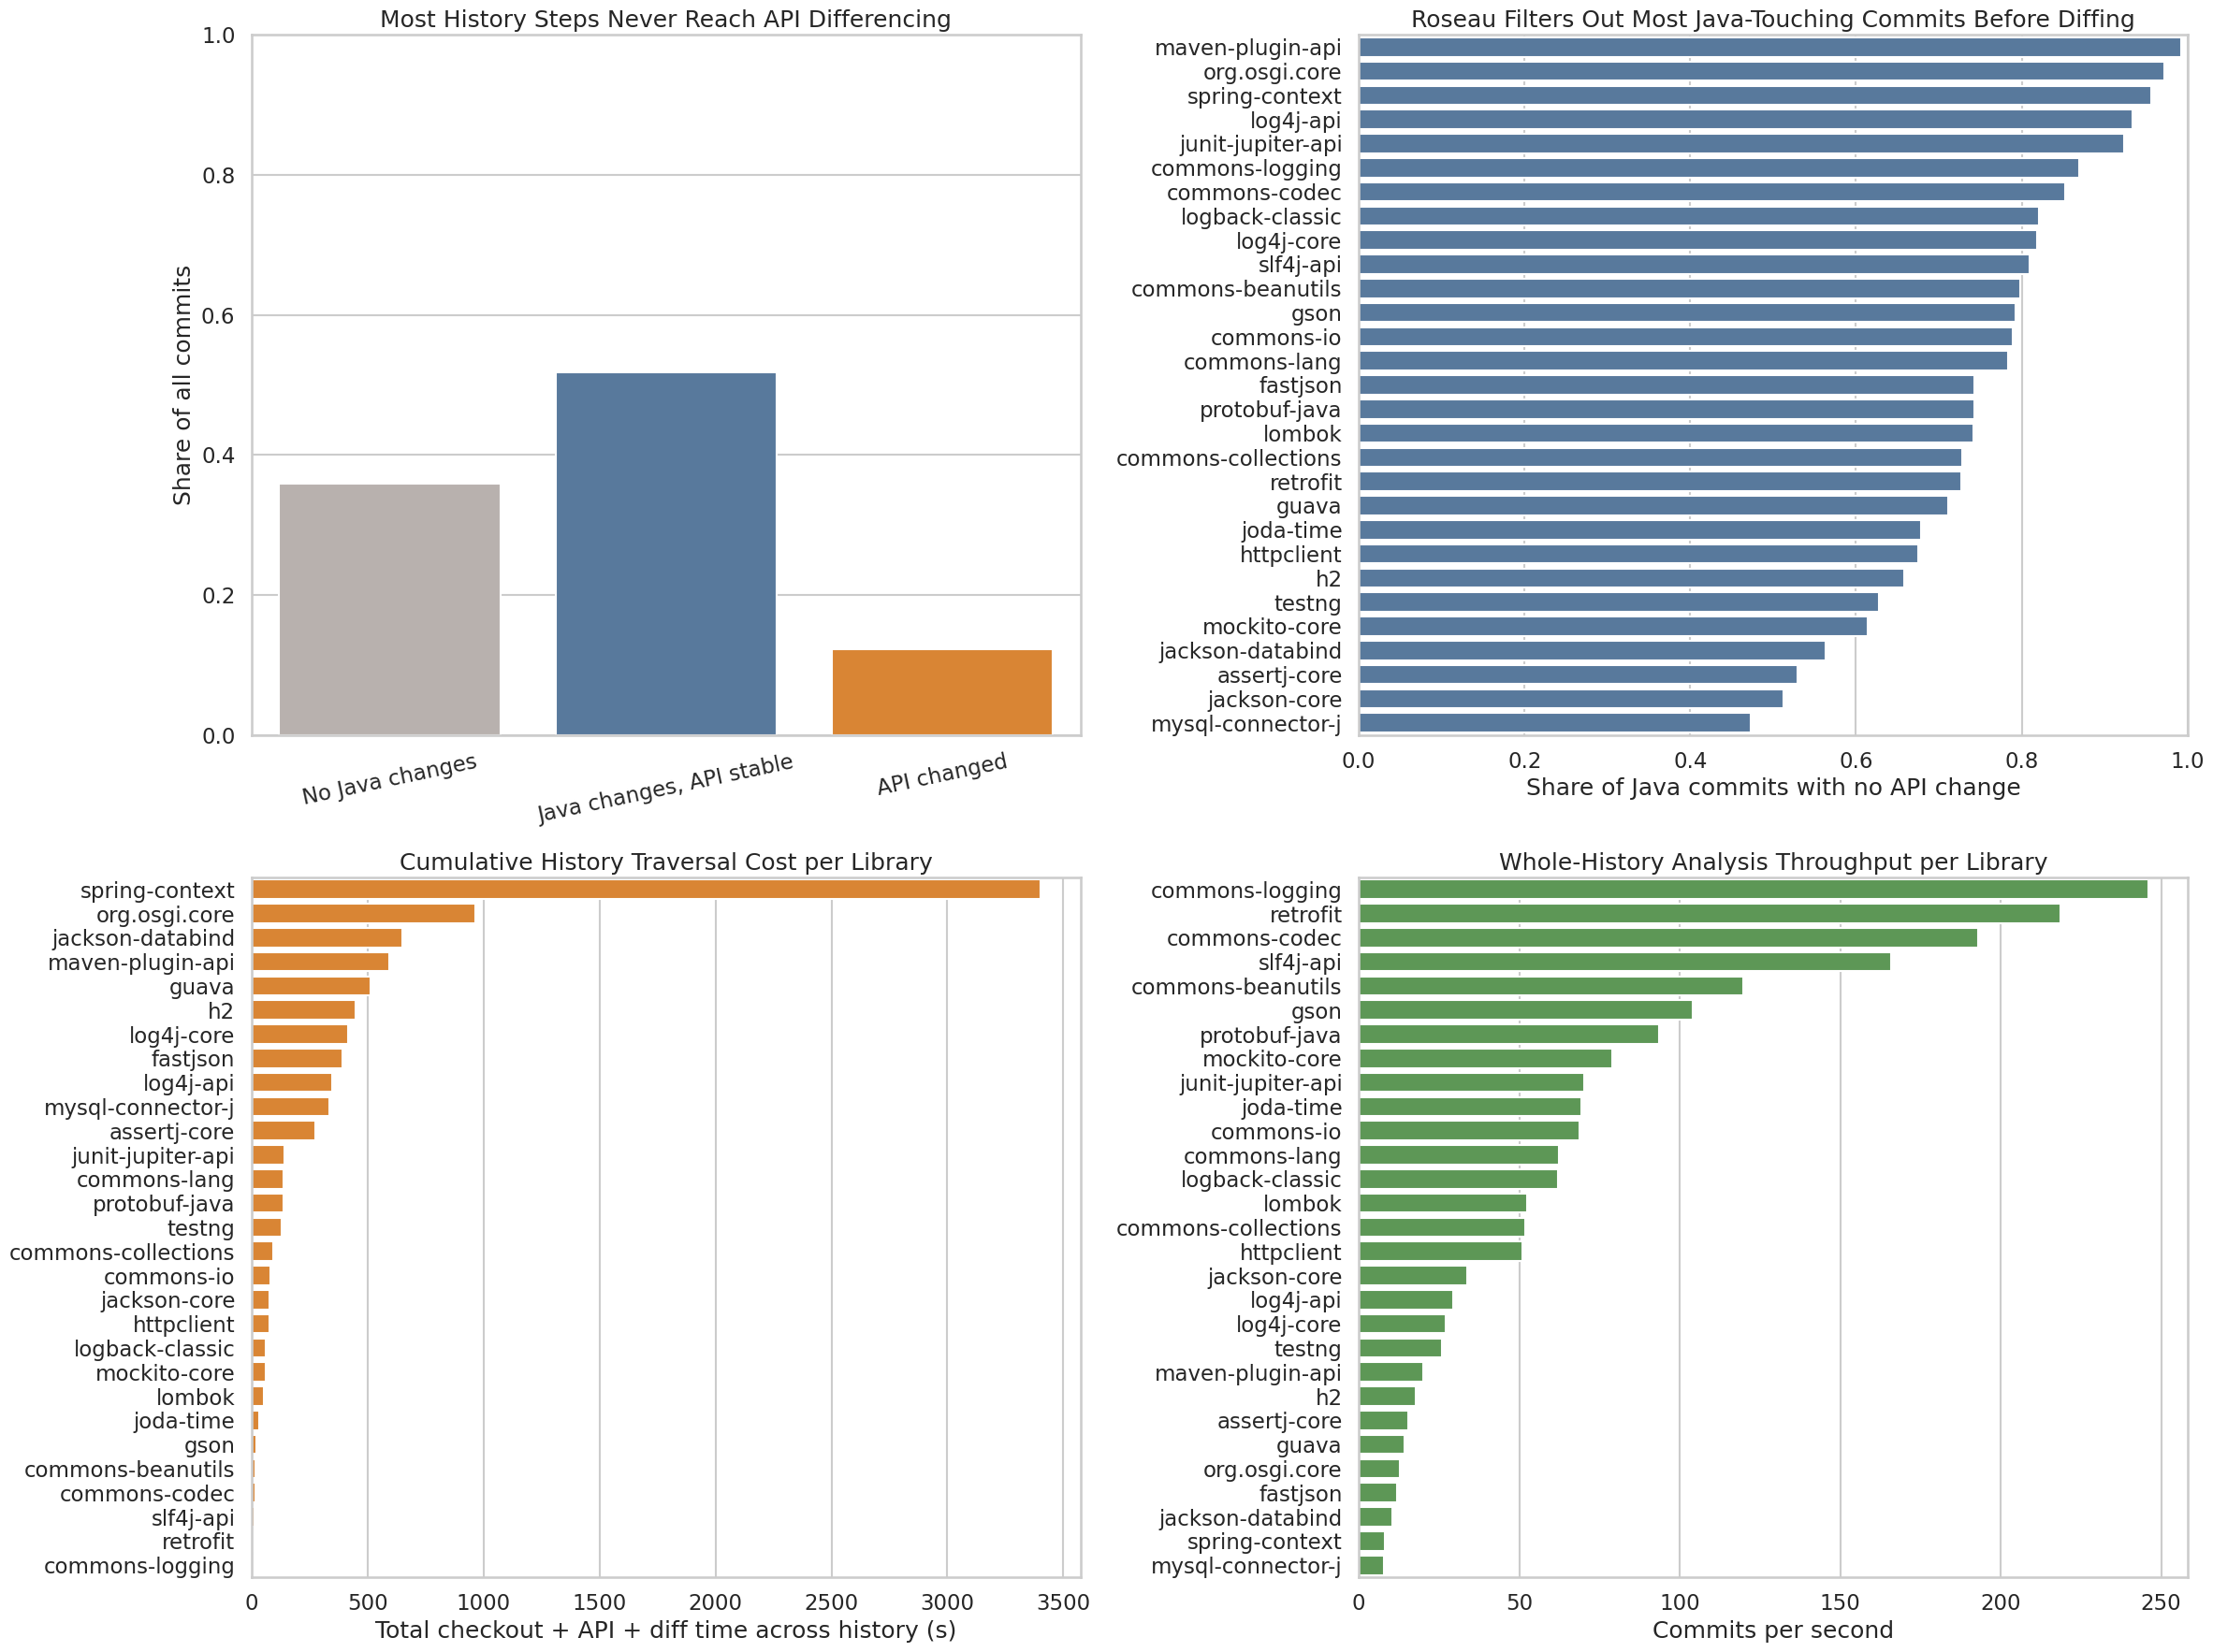

In [4]:
category_plot_df = category_summary.reset_index().copy()
java_filter_plot_df = library_history_df[library_history_df["java_commits"] > 0].sort_values(
    "java_filtered_before_diff_share", ascending=False
).reset_index()
analysis_cost_plot_df = library_history_df.sort_values("total_analysis_s", ascending=False).reset_index()
throughput_plot_df = library_history_df.sort_values("analysis_throughput_cps", ascending=False).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(24, 18))

sns.barplot(
    data=category_plot_df,
    x="label",
    y="share_all_commits",
    hue="label",
    palette=[CATEGORY_PALETTE[key] for key in CATEGORY_ORDER],
    dodge=False,
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Share of all commits")
axes[0, 0].set_title("Most History Steps Never Reach API Differencing")
axes[0, 0].tick_params(axis="x", rotation=12)

sns.barplot(
    data=java_filter_plot_df,
    y="library",
    x="java_filtered_before_diff_share",
    ax=axes[0, 1],
    color=CATEGORY_PALETTE["java_no_api_change"],
)
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_xlabel("Share of Java commits with no API change")
axes[0, 1].set_ylabel("")
axes[0, 1].set_title("Roseau Filters Out Most Java-Touching Commits Before Diffing")

sns.barplot(
    data=analysis_cost_plot_df,
    y="library",
    x="total_analysis_s",
    ax=axes[1, 0],
    color="#f58518",
)
axes[1, 0].set_xlabel("Total checkout + API + diff time across history (s)")
axes[1, 0].set_ylabel("")
axes[1, 0].set_title("Cumulative History Traversal Cost per Library")

sns.barplot(
    data=throughput_plot_df,
    y="library",
    x="analysis_throughput_cps",
    ax=axes[1, 1],
    color="#54a24b",
)
axes[1, 1].set_xlabel("Commits per second")
axes[1, 1].set_ylabel("")
axes[1, 1].set_title("Whole-History Analysis Throughput per Library")

plt.tight_layout()


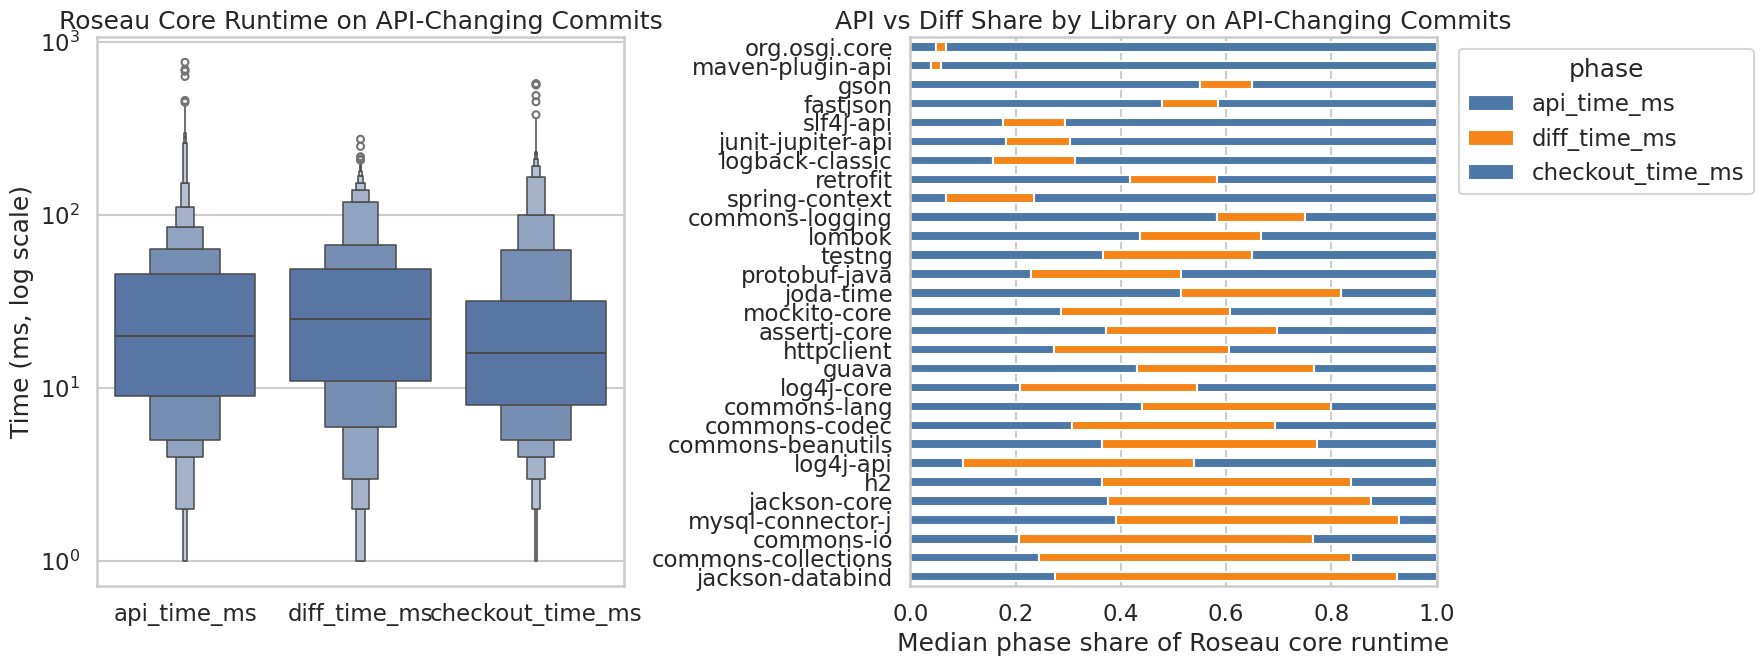

In [5]:
phase_long = phase_df.melt(
    id_vars=["library"],
    value_vars=CORE_PHASE_COLS,
    var_name="phase",
    value_name="time_ms",
)
phase_long = phase_long[phase_long["time_ms"] > 0]

library_phase_share_plot = library_phase_share.sort_values("diff_time_ms", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.boxenplot(data=phase_long, x="phase", y="time_ms", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].set_ylabel("Time (ms, log scale)")
axes[0].set_title("Roseau Core Runtime on API-Changing Commits")

library_phase_share_plot.plot(kind="barh", stacked=True, ax=axes[1], color=["#4c78a8", "#f58518"])
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Median phase share of Roseau core runtime")
axes[1].set_ylabel("")
axes[1].set_title("API vs Diff Share by Library on API-Changing Commits")
axes[1].legend(title="phase", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()


,api_time_spearman,diff_time_spearman,median_api_ms_when_zero,median_api_ms_when_positive,median_diff_ms_when_zero,median_diff_ms_when_positive
java_file_metric,,,,,,
Updated Java files,0.355,0.120,6.0,17.0,15.0,26.0
Deleted Java files,0.021,-0.091,16.0,19.0,26.0,18.0
Added Java files,0.005,-0.080,16.0,21.0,29.0,18.0


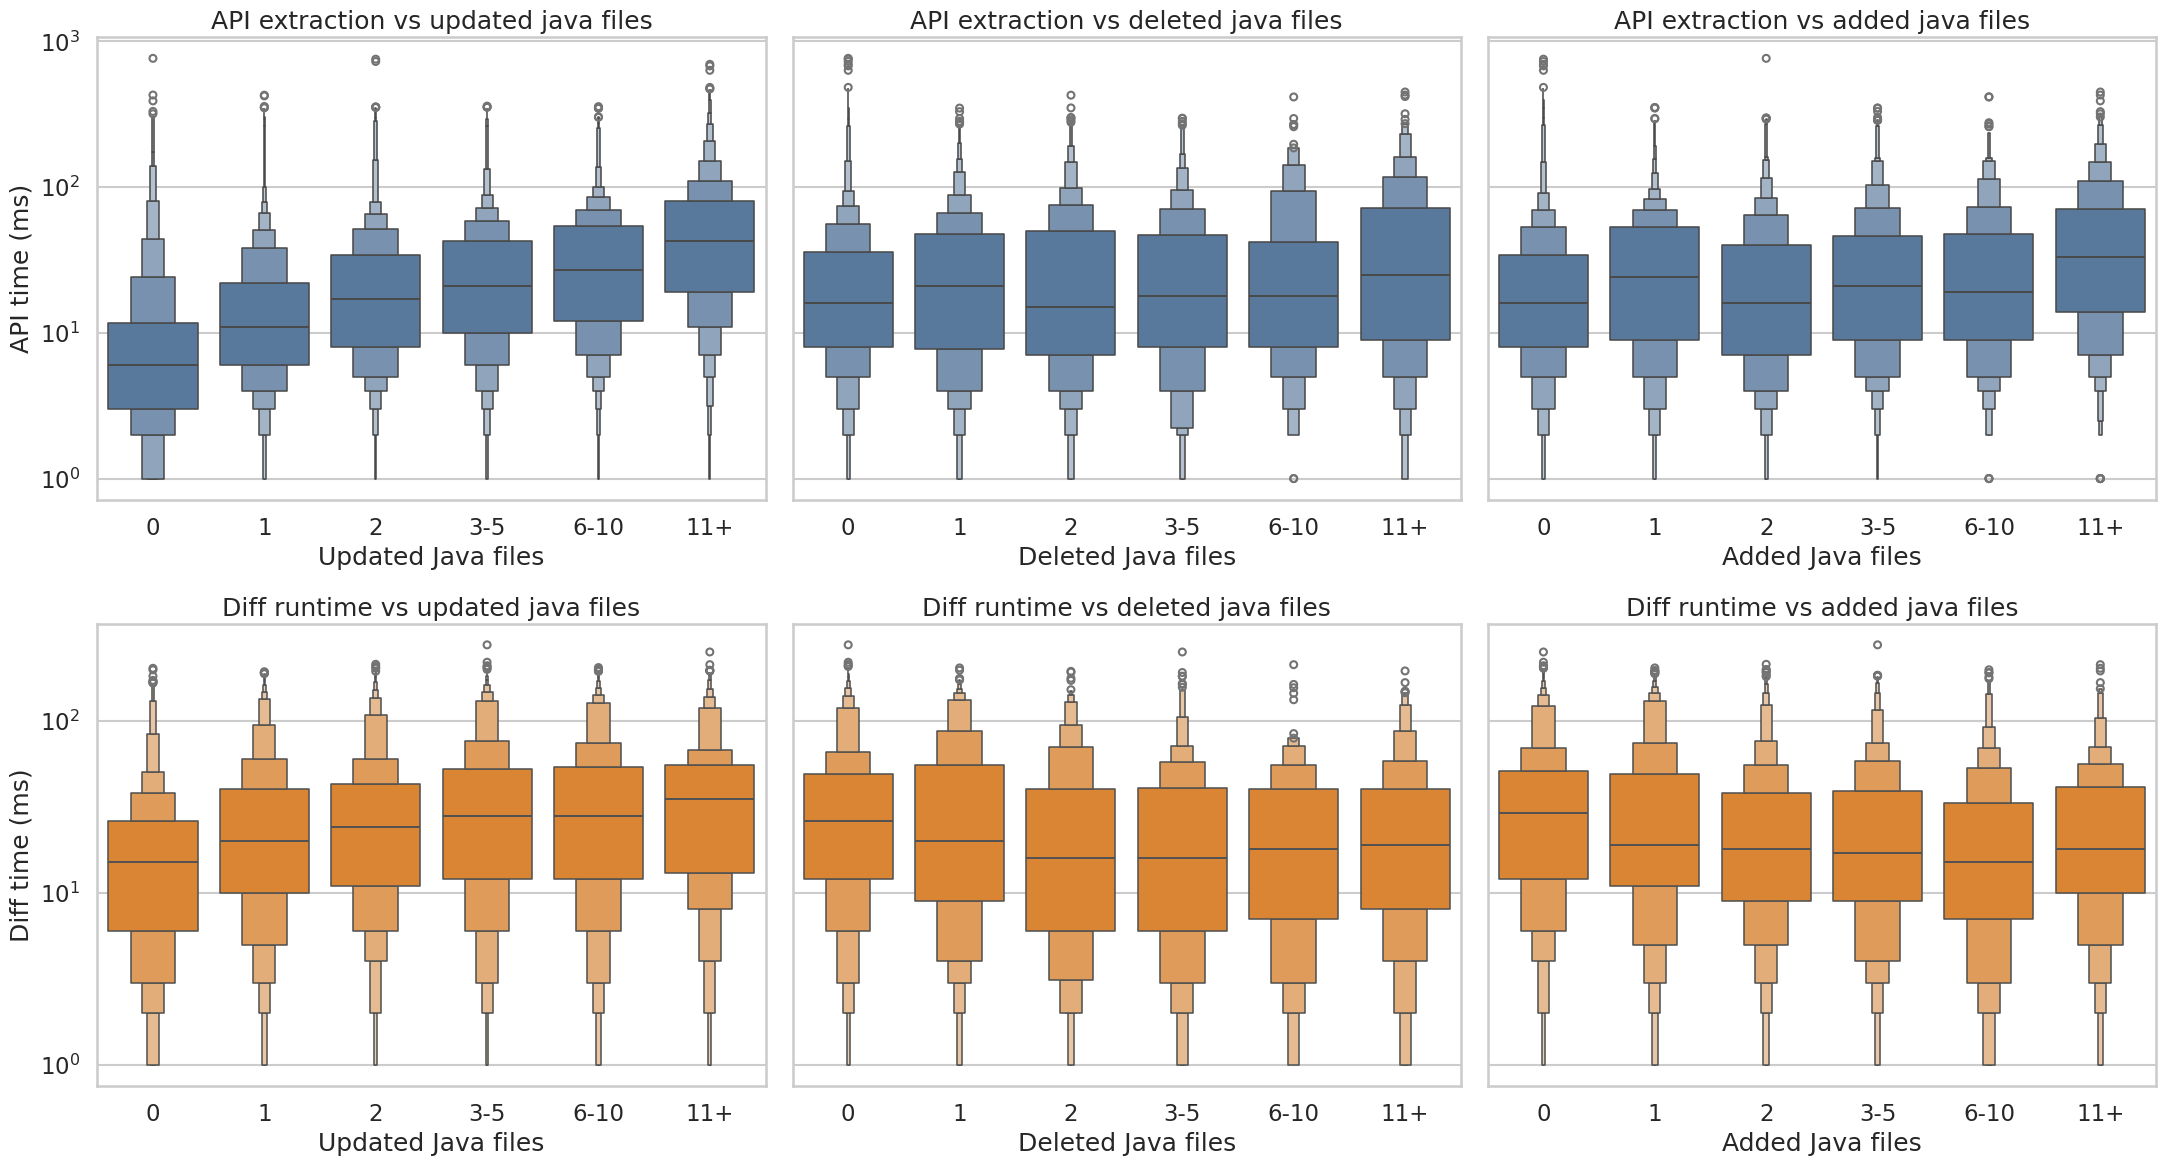

In [6]:
impact_rows = []
for column in JAVA_FILE_COUNT_COLS:
    api_subset = java_df[java_df["api_time_ms"] > 0]
    diff_subset = api_changed_df[api_changed_df["diff_time_ms"] > 0]
    impact_rows.append(
        {
            "java_file_metric": JAVA_FILE_LABELS[column],
            "api_time_spearman": safe_corr(api_subset, column, "api_time_ms", method="spearman"),
            "diff_time_spearman": safe_corr(diff_subset, column, "diff_time_ms", method="spearman"),
            "median_api_ms_when_zero": api_subset.loc[api_subset[column] == 0, "api_time_ms"].median(),
            "median_api_ms_when_positive": api_subset.loc[api_subset[column] > 0, "api_time_ms"].median(),
            "median_diff_ms_when_zero": diff_subset.loc[diff_subset[column] == 0, "diff_time_ms"].median(),
            "median_diff_ms_when_positive": diff_subset.loc[diff_subset[column] > 0, "diff_time_ms"].median(),
        }
    )
impact_summary = pd.DataFrame(impact_rows).set_index("java_file_metric").round(3)
display(impact_summary)

fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharey="row")

api_plot_df = java_df[java_df["api_time_ms"] > 0].copy()
diff_plot_df = api_changed_df[api_changed_df["diff_time_ms"] > 0].copy()

for col_idx, column in enumerate(JAVA_FILE_COUNT_COLS):
    api_box_df = api_plot_df[[column, "api_time_ms"]].copy()
    api_box_df["bucket"] = pd.cut(api_box_df[column], FILE_COUNT_BINS, labels=FILE_COUNT_BUCKETS)
    api_box_df = api_box_df.dropna(subset=["bucket"])

    sns.boxenplot(
        data=api_box_df,
        x="bucket",
        y="api_time_ms",
        ax=axes[0, col_idx],
        color="#4c78a8",
    )
    axes[0, col_idx].set_yscale("log")
    axes[0, col_idx].set_xlabel(JAVA_FILE_LABELS[column])
    axes[0, col_idx].set_ylabel("API time (ms)")
    axes[0, col_idx].set_title(f"API extraction vs {JAVA_FILE_LABELS[column].lower()}")

    diff_box_df = diff_plot_df[[column, "diff_time_ms"]].copy()
    diff_box_df["bucket"] = pd.cut(diff_box_df[column], FILE_COUNT_BINS, labels=FILE_COUNT_BUCKETS)
    diff_box_df = diff_box_df.dropna(subset=["bucket"])

    sns.boxenplot(
        data=diff_box_df,
        x="bucket",
        y="diff_time_ms",
        ax=axes[1, col_idx],
        color="#f58518",
    )
    axes[1, col_idx].set_yscale("log")
    axes[1, col_idx].set_xlabel(JAVA_FILE_LABELS[column])
    axes[1, col_idx].set_ylabel("Diff time (ms)")
    axes[1, col_idx].set_title(f"Diff runtime vs {JAVA_FILE_LABELS[column].lower()}")

plt.tight_layout()


## All-Library Runtime Profiles

The table and plots below keep **all libraries** in view and organize them by a few runtime dimensions that matter for interpretation:

- cumulative whole-history traversal cost,
- per-commit cost on API-changing commits,
- the share of Java-touching commits filtered before diffing,
- and the balance between API extraction and API differencing.

In [7]:
display(library_phase_summary)

highest_cost = library_phase_summary["total_analysis_min"].sort_values(ascending=False).head(5)
highest_median = library_phase_summary["median_core_ms"].sort_values(ascending=False).head(5)
highest_filter = library_phase_summary["java_filtered_before_diff_share"].sort_values(ascending=False).head(5)
highest_api_share = library_phase_summary["median_api_share"].sort_values(ascending=False).head(5)

lines = [
    f"- Libraries with the largest cumulative whole-history cost are **{', '.join(f'{lib} ({val:.1f} min)' for lib, val in highest_cost.items())}**.",
    f"- Libraries with the highest median API-changing commit cost are **{', '.join(f'{lib} ({val:.0f} ms)' for lib, val in highest_median.items())}**.",
    f"- Libraries that filter the largest share of Java commits before diffing are **{', '.join(f'{lib} ({val:.0%})' for lib, val in highest_filter.items())}**.",
    f"- The most API-dominated median phase splits are **{', '.join(f'{lib} ({val:.0%} API)' for lib, val in highest_api_share.items())}**.",
]

display(Markdown("\n".join(lines)))


,commits,java_commits,java_no_api_commits,api_changed_commits,java_filtered_before_diff_share,total_analysis_min,analysis_throughput_cps,analysis_ms_per_commit,total_core_min,median_core_ms,p95_core_ms,median_api_share,median_diff_share,corr_core_vs_api_size,corr_core_vs_java_file_churn,max_exported_symbols
library,,,,,,,,,,,,,,,,
spring-context,28055.0,22128.0,21158.0,970.0,0.956,56.718,8.244,121.300,56.718,165.0,271.00,0.068,0.167,0.791,0.489,3319.0
org.osgi.core,12459.0,7283.0,7079.0,204.0,0.972,16.081,12.913,77.441,16.081,161.0,241.85,0.050,0.019,0.777,0.540,674.0
jackson-databind,6751.0,5549.0,3124.0,2425.0,0.563,10.812,10.407,96.092,10.812,164.0,404.00,0.275,0.650,0.638,0.132,9264.0
maven-plugin-api,12030.0,7143.0,7083.0,60.0,0.992,9.927,20.197,49.511,9.927,53.0,105.80,0.039,0.019,0.376,0.468,270.0
guava,7253.0,6511.0,4632.0,1879.0,0.711,8.544,14.148,70.682,8.544,106.0,172.10,0.430,0.336,0.463,0.772,5082.0
h2,8024.0,6992.0,4599.0,2393.0,0.658,7.486,17.864,55.977,7.486,108.0,212.00,0.364,0.473,0.632,0.566,10704.0
log4j-core,11238.0,7071.0,5787.0,1284.0,0.818,6.946,26.964,37.087,6.946,78.5,191.85,0.208,0.338,0.920,0.308,5757.0
fastjson,4612.0,3574.0,2654.0,920.0,0.743,6.526,11.779,84.895,6.526,143.5,212.00,0.479,0.106,0.859,0.281,4889.0
log4j-api,10292.0,7029.0,6567.0,462.0,0.934,5.815,29.500,33.898,5.815,92.0,190.95,0.101,0.438,0.892,0.383,2418.0


- Libraries with the largest cumulative whole-history cost are **spring-context (56.7 min), org.osgi.core (16.1 min), jackson-databind (10.8 min), maven-plugin-api (9.9 min), guava (8.5 min)**.
- Libraries with the highest median API-changing commit cost are **protobuf-java (194 ms), mysql-connector-j (173 ms), spring-context (165 ms), jackson-databind (164 ms), org.osgi.core (161 ms)**.
- Libraries that filter the largest share of Java commits before diffing are **maven-plugin-api (99%), org.osgi.core (97%), spring-context (96%), log4j-api (93%), junit-jupiter-api (92%)**.
- The most API-dominated median phase splits are **commons-logging (58% API), gson (55% API), joda-time (52% API), fastjson (48% API), commons-lang (44% API)**.

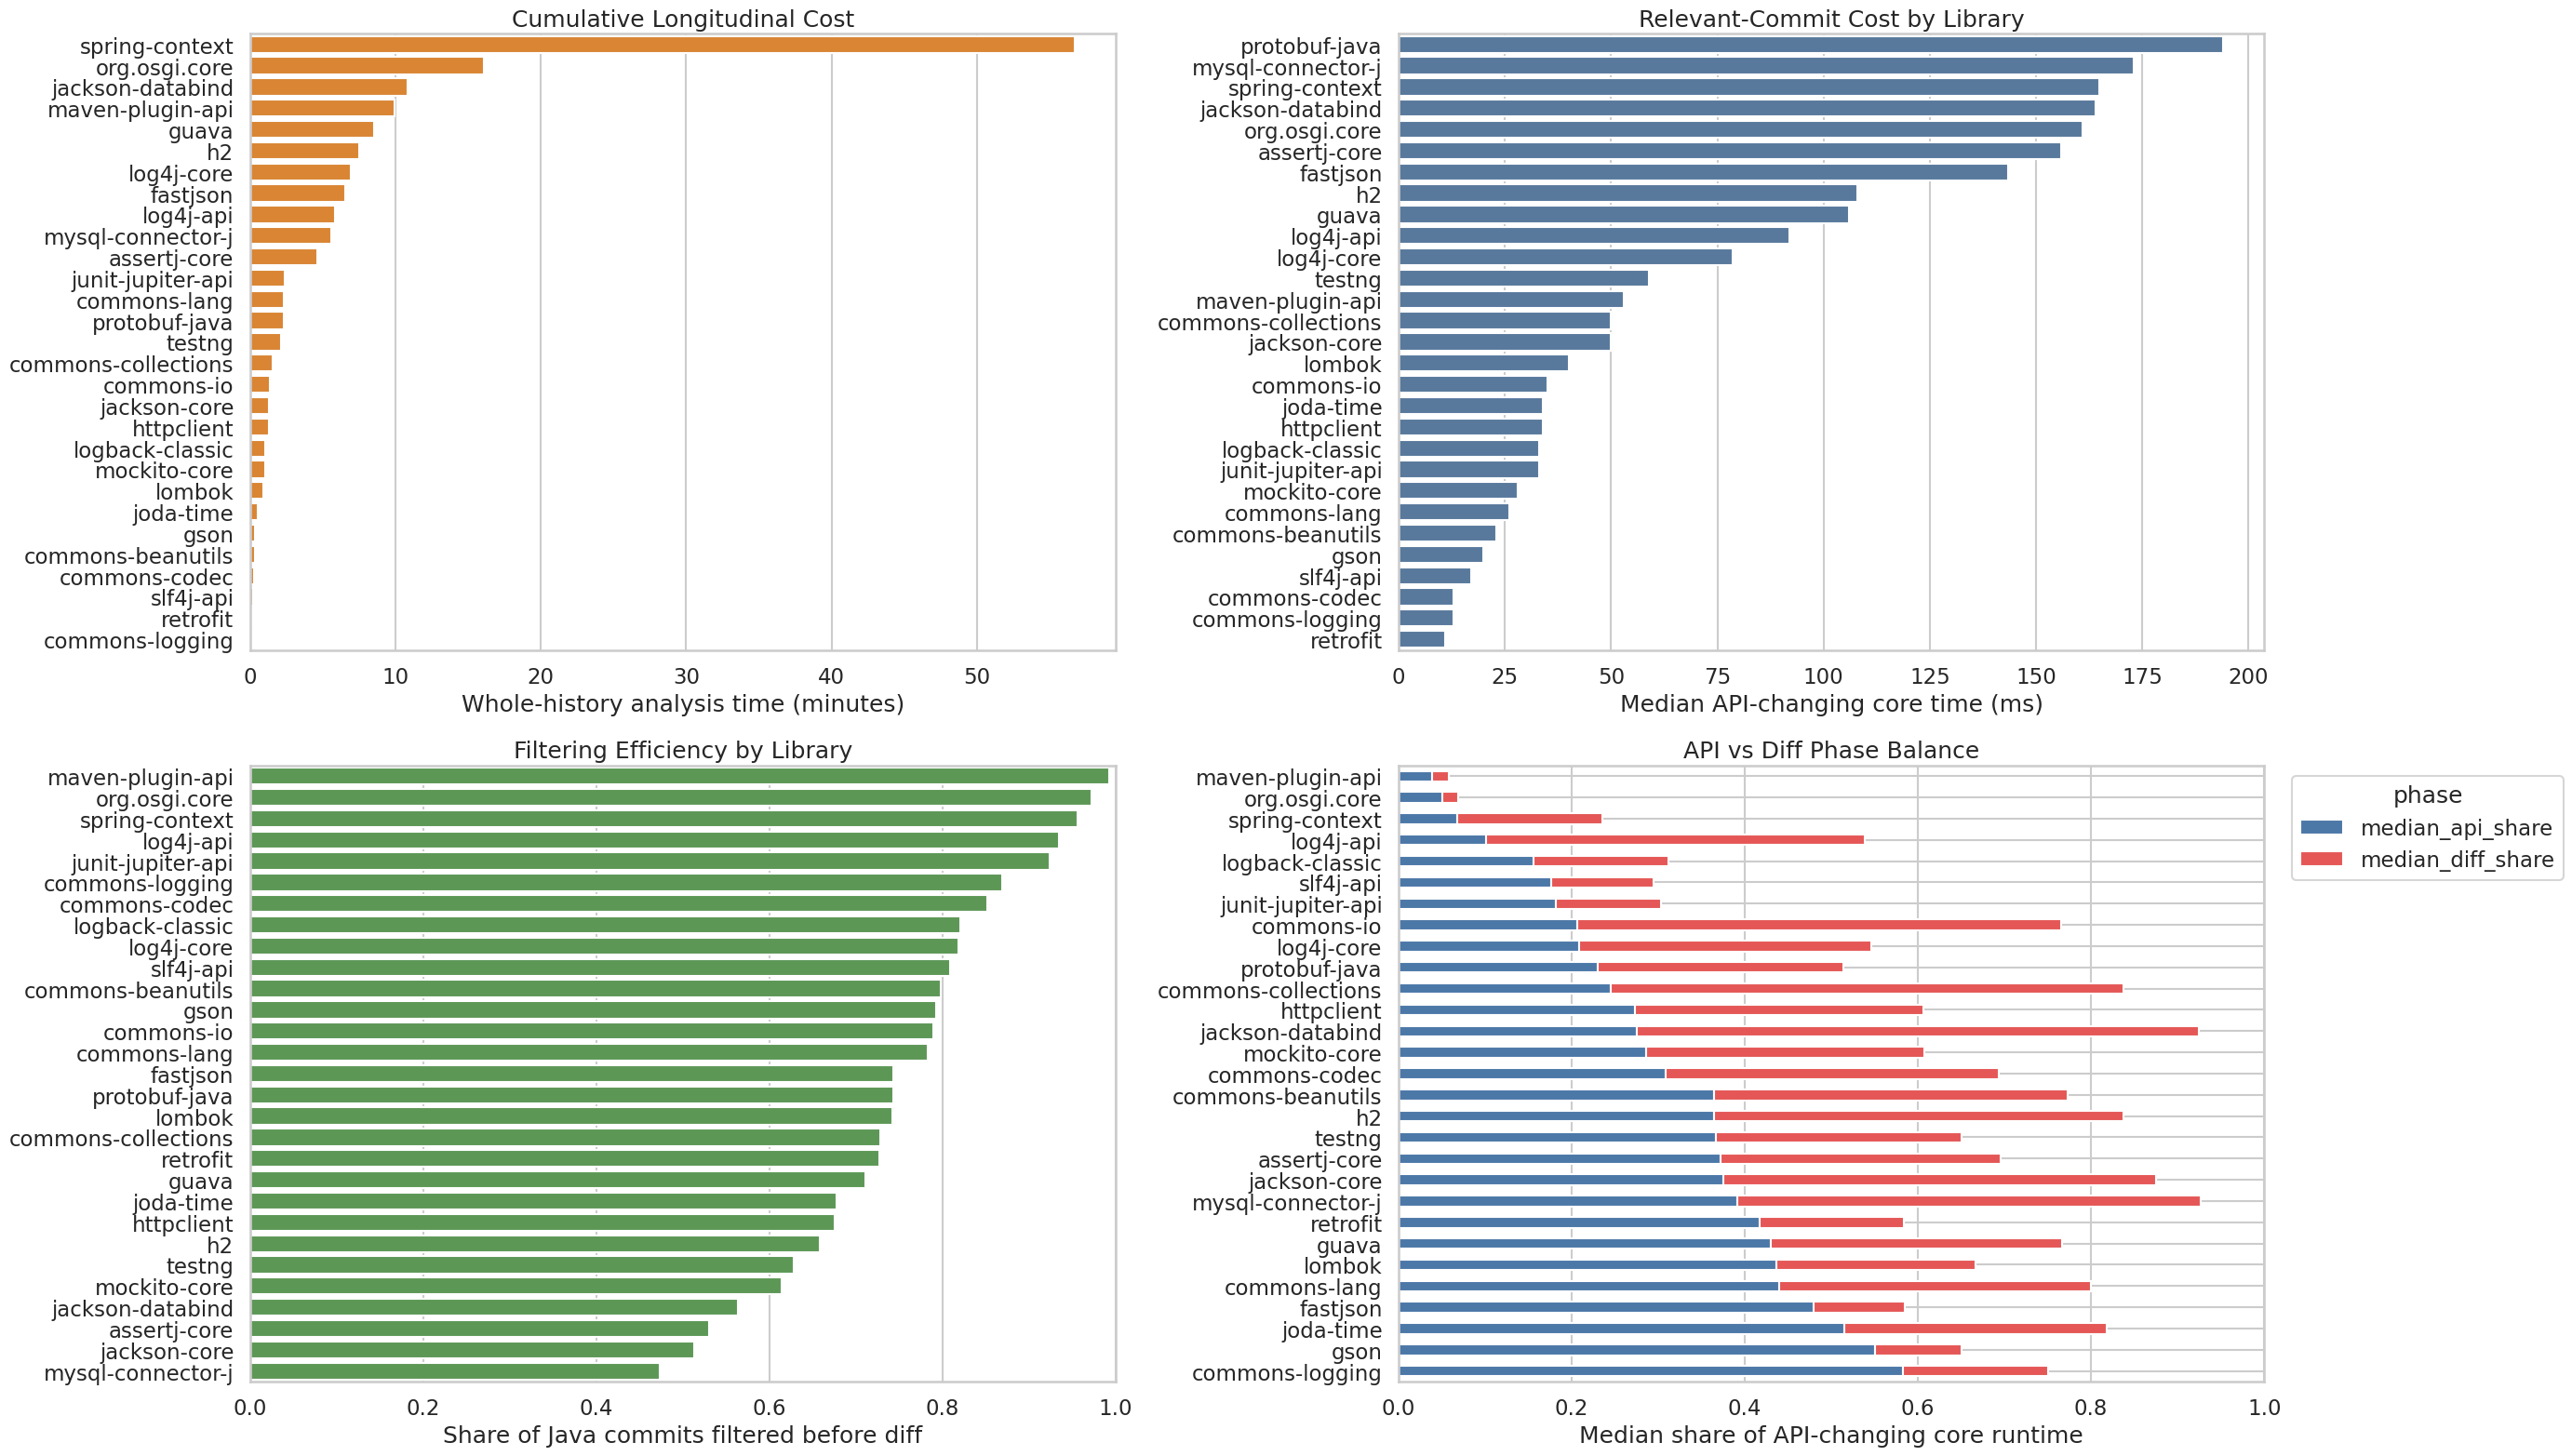

In [8]:
plot_df = library_phase_summary.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(28, max(16, 0.45 * len(plot_df))))

sns.barplot(
    data=plot_df.sort_values("total_analysis_min", ascending=False),
    y="library",
    x="total_analysis_min",
    ax=axes[0, 0],
    color="#f58518",
)
axes[0, 0].set_xlabel("Whole-history analysis time (minutes)")
axes[0, 0].set_ylabel("")
axes[0, 0].set_title("Cumulative Longitudinal Cost")

sns.barplot(
    data=plot_df.sort_values("median_core_ms", ascending=False),
    y="library",
    x="median_core_ms",
    ax=axes[0, 1],
    color="#4c78a8",
)
axes[0, 1].set_xlabel("Median API-changing core time (ms)")
axes[0, 1].set_ylabel("")
axes[0, 1].set_title("Relevant-Commit Cost by Library")

sns.barplot(
    data=plot_df.sort_values("java_filtered_before_diff_share", ascending=False),
    y="library",
    x="java_filtered_before_diff_share",
    ax=axes[1, 0],
    color="#54a24b",
)
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_xlabel("Share of Java commits filtered before diff")
axes[1, 0].set_ylabel("")
axes[1, 0].set_title("Filtering Efficiency by Library")

phase_share_plot = library_phase_summary[["median_api_share", "median_diff_share"]].sort_values("median_api_share", ascending=False)
phase_share_plot.plot(kind="barh", stacked=True, ax=axes[1, 1], color=["#4c78a8", "#e45756"])
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_xlabel("Median share of API-changing core runtime")
axes[1, 1].set_ylabel("")
axes[1, 1].set_title("API vs Diff Phase Balance")
axes[1, 1].legend(title="phase", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()


## Tables

- a **library-history summary table** that distinguishes Java-touching commits from API-changing commits,
- a **breaking vs non-breaking comparison** on API-changing commits,
- a **slowest-commit outlier table** enriched with Java file churn

In [9]:
breaks_compare = phase_df.groupby("has_breaks").agg(
    commits=("commit_sha", "count"),
    median_core_ms=("core_time_ms", "median"),
    p95_core_ms=("core_time_ms", q95),
    median_api_ms=("api_time_ms", "median"),
    median_diff_ms=("diff_time_ms", "median"),
    median_java_files=("java_file_churn", "median"),
).round(2)

slowest_commits = phase_df.sort_values("core_time_ms", ascending=False)[[
    "library",
    "commit_sha",
    "date_utc",
    "updated_java_files_count",
    "deleted_java_files_count",
    "created_java_files_count",
    "exported_symbols_count",
    "files_changed",
    "api_breaking_changes_count",
    "excluded_breaking_changes_count",
    "all_breaking_changes_count",
    "api_time_ms",
    "diff_time_ms",
    "core_time_ms",
]].head(15)

display(library_history_df)
display(breaks_compare)
display(slowest_commits)

,commits,java_commits,java_no_api_commits,api_changed_commits,api_changed_share_all_commits,java_filtered_before_diff_share,api_changed_share_within_java,total_analysis_s,total_analysis_min,analysis_throughput_cps,...,median_api_ms,median_diff_ms,median_core_ms,p95_core_ms,median_java_files_java_commits,median_java_files_api_changed,max_exported_symbols,api_breaking_changes_total,excluded_breaking_changes_total,excluded_or_internal_break_share
library,,,,,,,,,,,,,,,,,,,,,
spring-context,28055.0,22128.0,21158.0,970.0,0.035,0.956,0.044,3403.060,56.718,8.244,...,12.0,27.0,165.0,271.00,2.0,5.0,3319.0,3174.0,0.0,0.000
org.osgi.core,12459.0,7283.0,7079.0,204.0,0.016,0.972,0.028,964.832,16.081,12.913,...,8.0,3.0,161.0,241.85,1.0,2.0,674.0,455.0,0.0,0.000
jackson-databind,6751.0,5549.0,3124.0,2425.0,0.359,0.563,0.437,648.716,10.812,10.407,...,40.0,104.0,164.0,404.00,2.0,4.0,9264.0,32414.0,3070.0,0.087
maven-plugin-api,12030.0,7143.0,7083.0,60.0,0.005,0.992,0.008,595.623,9.927,20.197,...,3.0,1.0,53.0,105.80,2.0,8.0,270.0,77.0,0.0,0.000
guava,7253.0,6511.0,4632.0,1879.0,0.259,0.711,0.289,512.653,8.544,14.148,...,45.0,36.0,106.0,172.10,2.0,4.0,5082.0,556.0,1634.0,0.746
h2,8024.0,6992.0,4599.0,2393.0,0.298,0.658,0.342,449.159,7.486,17.864,...,26.0,52.0,108.0,212.00,2.0,6.0,10704.0,35406.0,0.0,0.000
log4j-core,11238.0,7071.0,5787.0,1284.0,0.114,0.818,0.182,416.783,6.946,26.964,...,13.0,26.0,78.5,191.85,1.0,3.0,5757.0,3267.0,207.0,0.060
fastjson,4612.0,3574.0,2654.0,920.0,0.199,0.743,0.257,391.538,6.526,11.779,...,64.0,15.0,143.5,212.00,2.0,6.0,4889.0,1906.0,155.0,0.075
log4j-api,10292.0,7029.0,6567.0,462.0,0.045,0.934,0.066,348.879,5.815,29.500,...,8.0,39.0,92.0,190.95,1.0,4.0,2418.0,1998.0,83.0,0.040


,commits,median_core_ms,p95_core_ms,median_api_ms,median_diff_ms,median_java_files
has_breaks,,,,,,
False,13852,73.0,224.0,18.0,24.0,3.0
True,8923,88.0,268.0,23.0,26.0,6.0


,library,commit_sha,date_utc,updated_java_files_count,deleted_java_files_count,created_java_files_count,exported_symbols_count,files_changed,api_breaking_changes_count,excluded_breaking_changes_count,all_breaking_changes_count,api_time_ms,diff_time_ms,core_time_ms
43992,guava,2cc8c5eddb587db3ac12dacdd5563e79a4681ec4,2024-12-22 03:38:46+00:00,1317,0,0,5077,1317,0,0,0,697,42,1231
43986,guava,ce43463a9a884dacab6b3d1ca898d975cb2b071f,2024-12-21 03:10:51+00:00,1180,0,0,5077,1180,0,0,0,680,42,1103
43990,guava,d997ad9367c1369fca227605be4713c52b235e49,2024-12-21 17:16:20+00:00,673,0,0,5077,673,0,0,0,634,42,974
180354,spring-context,bc5d771a0639c6e47eda2b610c221a4515384abb,2024-12-19 10:07:23+00:00,3439,0,0,3262,3459,0,0,0,251,31,858
44119,guava,7a71ea0bfab8618765c2841111f998e484af6257,2025-03-19 17:26:38+00:00,0,0,2,5072,9,0,3,3,766,38,849
41759,guava,6f22af40e1526b8c194e9e36d457bcd37680c6a3,2017-12-07 20:37:46+00:00,601,0,0,4682,601,0,0,0,401,41,707
52392,h2,6417c157eca534832af35c783976efdfd628c378,2023-01-15 05:20:07+00:00,1148,0,0,10498,1623,4,0,4,461,65,705
64037,jackson-databind,a27694cd15c15fff7cc1ae3e921d0a85037cf890,2023-01-27 23:44:04+00:00,3,0,0,7871,3,0,0,0,28,104,698
63907,jackson-databind,17dead6bb1d5bc2eea78c886250ea1b682c5d3a1,2022-07-15 00:24:08+00:00,68,1042,1042,7770,2158,525,55,580,292,1,640
44272,guava,fb062c0da22c2f38ff0c6f411df8683d8ee144f6,2025-08-07 16:05:33+00:00,565,0,0,5073,565,0,0,0,321,41,633
